# 02 · The Product Mix — the showpiece

A company makes several products, each earning a profit and consuming limited
resources, and must decide **how much of each to make** to maximise profit.

The forecasting reflex is to predict demand and guess a mix. But the question was
never *"what will demand be"* — it is *"what should we do"*, and that has a
**provably optimal answer**. We write the problem down as a linear program and a
free solver returns the profit-maximising mix in milliseconds, guaranteed optimal.

We build the **same** problem twice — once as readable algebra in **PuLP**, once as
raw matrices for **SciPy** — to show they are two descriptions of one thing.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module="pulp")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from src.datasets.scenarios import product_mix_scenario
from src.exporters import save_fig, save_json
from src.models import product_mix
from src.solvers.backends import solve
from src.visualisation import plot_feasible_region

scenario = product_mix_scenario()
save_json(
    {
        "profit_per_unit": scenario.profit,
        "resource_usage": scenario.usage,
        "resource_limits": scenario.capacity,
        "known_optimum": scenario.optimum,
        "known_mix": scenario.optimal_mix,
    },
    "02_product_mix_inputs",
)
scenario.profit, scenario.capacity

({'doors': 3.0, 'windows': 5.0},
 {'plant1': 4.0, 'plant2': 12.0, 'plant3': 18.0})

## Built once, as readable algebra (PuLP)

PuLP lets you write the model almost the way you would on paper: declare the
decision variables, add the objective, add the constraints, call `solve`.

In [2]:
import pulp

prob = pulp.LpProblem("product_mix", pulp.LpMaximize)

# decision variables (how many of each product, continuous and non-negative)
d = pulp.LpVariable("doors", lowBound=0)
w = pulp.LpVariable("windows", lowBound=0)

# objective: maximise profit
prob += 3 * d + 5 * w

# constraints: each plant's hours are limited
prob += d <= 4, "plant1"
prob += 2 * w <= 12, "plant2"
prob += 3 * d + 2 * w <= 18, "plant3"

prob.solve(pulp.PULP_CBC_CMD(msg=False))

pulp_mix = {"doors": d.value(), "windows": w.value()}
pulp_profit = pulp.value(prob.objective)
print("status :", pulp.LpStatus[prob.status])
print("mix    :", pulp_mix)
print("profit :", pulp_profit)

status : Optimal
mix    : {'doors': 2.0, 'windows': 6.0}
profit : 36.0


## Built again, as raw matrices (SciPy)

SciPy's `linprog` takes the same model in matrix form: a cost vector `c`, an
inequality matrix `A` and a right-hand side `b` for `A x <= b`. `linprog`
*minimises*, so to maximise profit we minimise `-c`. The matrices are just the
coefficients from the algebra above.

In [3]:
from scipy.optimize import linprog

c, a, b = product_mix.as_matrices(scenario)
print("c (profit) =", c)
print("A (usage)  =\n", a)
print("b (limits) =", b)

res = linprog(-c, A_ub=a, b_ub=b, bounds=[(0, None), (0, None)], method="highs")
scipy_mix = {"doors": res.x[0], "windows": res.x[1]}
scipy_profit = -res.fun
print("\nmix    :", {k: round(v, 6) for k, v in scipy_mix.items()})
print("profit :", round(scipy_profit, 6))

c (profit) = [3. 5.]
A (usage)  =
 [[1. 0.]
 [0. 2.]
 [3. 2.]]
b (limits) = [ 4. 12. 18.]

mix    : {'doors': np.float64(2.0), 'windows': np.float64(6.0)}
profit : 36.0


## Same problem, same answer — verified

Readable algebra and raw matrices return the identical optimum, and it matches the
analytic optimum (36 at 2 doors, 6 windows). This is the moment optimization stops
being theory: a real decision, a free solver, a provably best answer.

In [4]:
assert abs(pulp_profit - scipy_profit) < 1e-6
assert abs(pulp_profit - scenario.optimum) < 1e-6

results = {
    "pulp": {"profit": pulp_profit, "mix": pulp_mix},
    "scipy": {"profit": scipy_profit, "mix": scipy_mix},
    "known_optimum": scenario.optimum,
    "pulp_scipy_agree": abs(pulp_profit - scipy_profit) < 1e-6,
    "matches_known_optimum": abs(pulp_profit - scenario.optimum) < 1e-6,
}
save_json(results, "02_product_mix_results")
print("verified: both formulations agree and match the known optimum of", scenario.optimum)

verified: both formulations agree and match the known optimum of 36.0


## The optimal mix, and where it sits

The optimum is **2 doors and 6 windows**. On the feasible region it is exactly the
corner notebook 01 pointed to — the solver found it directly.

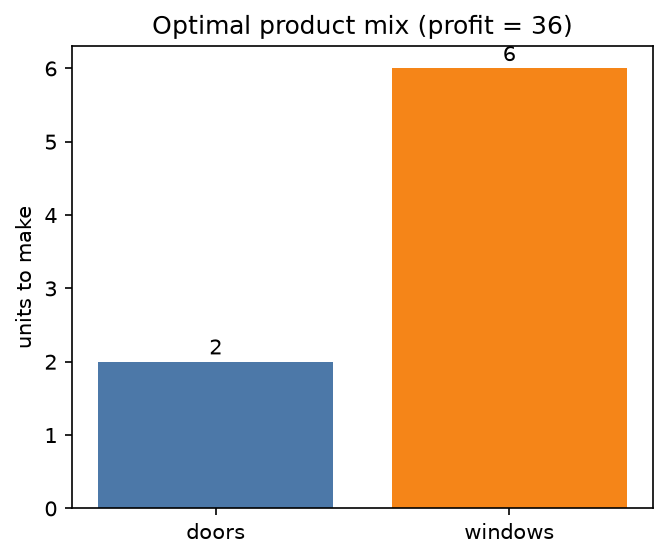

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
names = list(pulp_mix)
ax.bar(names, [pulp_mix[n] for n in names], color=["#4c78a8", "#f58518"])
ax.set_ylabel("units to make")
ax.set_title(f"Optimal product mix (profit = {pulp_profit:.0f})")
for i, n in enumerate(names):
    ax.text(i, pulp_mix[n] + 0.1, f"{pulp_mix[n]:.0f}", ha="center")
path = save_fig(fig, "02_optimal_mix")
plt.close(fig)
Image(str(path))

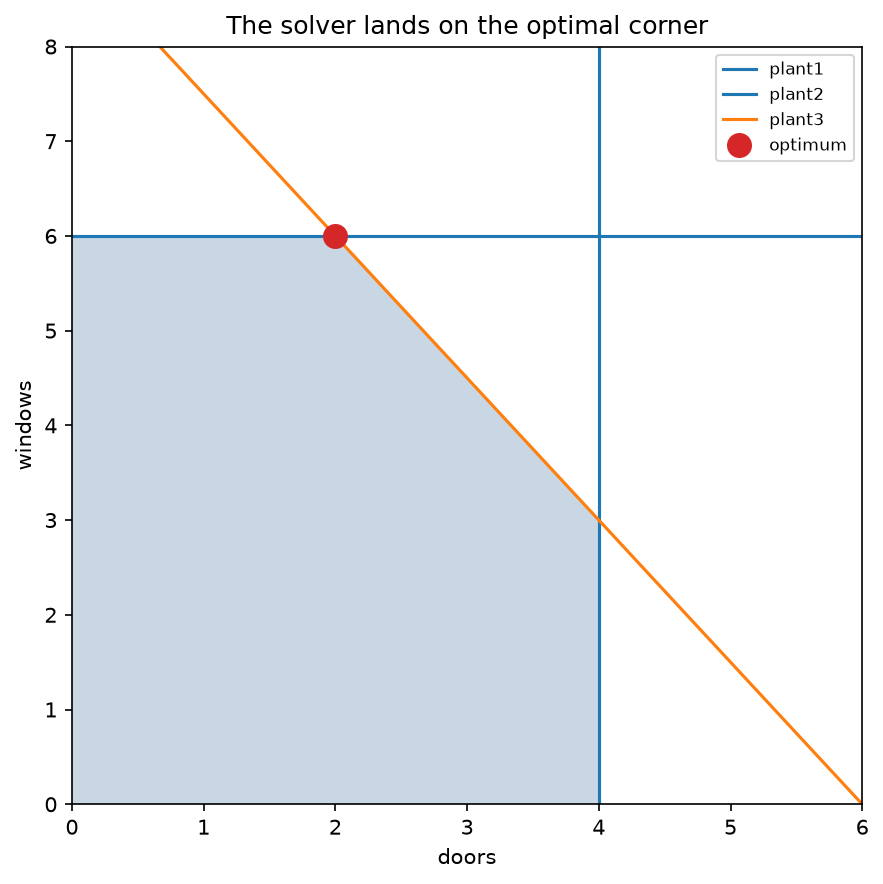

In [6]:
lp = product_mix.build(scenario)
solution = solve(lp, backend="scipy")  # the library wraps exactly the model above
fig = plot_feasible_region(lp, solution, x_max=6, y_max=8)
fig.axes[0].set_title("The solver lands on the optimal corner")
path = save_fig(fig, "02_feasible_region_solved")
plt.close(fig)
Image(str(path))

## The reframe

A forecasting model, however sophisticated, would have answered *"what will demand
be"* — a question nobody asked. The question was *"what should we make"*, and it has
an exact answer a solver already knows.

In **notebook 03** we ask the solved model one more question — *where is my
bottleneck and what is it worth?* — and get the **shadow prices**, the output no
predictive model can give.